### Imports

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

### Configuration

In [ ]:
DATASET_DIR = "../dataset_stage1"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
SEED = 42

### Data Augmentation

In [ ]:
# Data augmentation is only applied to the training dataset

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

In [ ]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

Found 1600 files belonging to 2 classes.


In [ ]:
val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

Found 200 files belonging to 2 classes.


In [ ]:
test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

Found 200 files belonging to 2 classes.


### Prefetch for Performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Load pretrained MobileNet (ImageNet weights)

` What this means:`
- weights="imagenet"
    - Loads knowledge from ~1.4 million images (edges, textures, shapes)
- You are not training from scratch   
- This is transfer learning

`Why it matters for you:`
- Your dataset is small (500–1000 images)
- ImageNet features generalize well to trash objects
- Faster training + higher accuracy

### Freeze base layers
`What this does:`
- Prevents MobileNet’s weights from changing
- Only the new classifier head will learn

`Why this is correct for Stage 1:`
- Stage 1 is coarse classification
- You want stable, general visual features
- Prevents overfitting on a small dataset

> Defense-ready explanation:
> 
> “The pretrained MobileNet layers were frozen to preserve general visual features and reduce overfitting given the limited dataset size.”

In [ ]:
# Freeze base model (Stage 1: only train classifier head)

base_model = MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

### Add binary classification head (sigmoid)
`Breakdown of each layer:`
- GlobalAveragePooling2D
    - Converts feature maps → single feature vector
    - Reduces parameters
    - Prevents overfitting

- Dropout (0.2)
    - Randomly disables 20% of neurons during training
    - Improves generalization

- Dense(1, sigmoid)
    - Outputs a probability between 0 and 1
    - Interpretation:
        - 0 → non-recyclable
        - 1 → recyclable

- Why sigmoid (not softmax):
    - Binary classification
    - One output neuron is sufficient

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

### Compile model

- Optimizer: Adam
    - Adaptive learning rate
    - Works well for transfer learning

- Learning rate = 1e-3
    - Fast learning for new classifier head
    - Safe because base model is frozen

- Loss: binary_crossentropy
    - Correct loss for sigmoid + binary labels

- Metrics:
    - Accuracy → overall correctness
    - Precision → “when I say recyclable, am I correct?”
    - Recall → “did I miss recyclable items?”
    
`These metrics are important for waste classification.`

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 2,997,313 (11.43 MB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
checkpoint_path = "models/stage1_mobilenetv3_best.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.6235 - loss: 0.6846 - precision: 0.6052 - recall: 0.5425
Epoch 1: val_loss improved from None to 0.48086, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 971ms/step - accuracy: 0.6938 - loss: 0.5848 - precision: 0.6947 - recall: 0.6913 - val_accuracy: 0.7850 - val_loss: 0.4809 - val_precision: 0.7478 - val_recall: 0.8600 - learning_rate: 0.0010
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.8370 - loss: 0.3898 - precision: 0.8187 - recall: 0.8516
Epoch 2: val_loss improved from 0.48086 to 0.39023, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 726ms/step - accuracy: 0.8313 - loss: 0.3867 - precision: 0.8264 - recall: 0.8388 - val_accuracy: 0.8250 - val_loss: 0.3902 - val_precision: 0.7876 - val_recall: 0.8900 - learning_rate: 0.0010
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.8379 - loss: 0.3498 - precision: 0.8133 - recall: 0.8595
Epoch 3: val_loss improved from 0.39023 to 0.34819, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 779ms/step - accuracy: 0.8413 - loss: 0.3534 - precision: 0.8305 - recall: 0.8575 - val_accuracy: 0.8450 - val_loss: 0.3482 - val_precision: 0.8053 - val_recall: 0.9100 - learning_rate: 0.0010
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8743 - loss: 0.2926 - precision: 0.8545 - recall: 0.8965
Epoch 4: val_loss improved from 0.34819 to 0.33349, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 652ms/step - accuracy: 0.8694 - loss: 0.2973 - precision: 0.8671 - recall: 0.8725 - val_accuracy: 0.8450 - val_loss: 0.3335 - val_precision: 0.8000 - val_recall: 0.9200 - learning_rate: 0.0010
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8870 - loss: 0.2830 - precision: 0.8623 - recall: 0.9137
Epoch 5: val_loss improved from 0.33349 to 0.30970, saving model to models/stage1_mobilenetv3_best.h5


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 715ms/step - accuracy: 0.9112 - loss: 0.2338 - precision: 0.9032 - recall: 0.9212 - val_accuracy: 0.8800 - val_loss: 0.2687 - val_precision: 0.8455 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9059 - loss: 0.2208 - precision: 0.8904 - recall: 0.9230
Epoch 9: val_loss improved from 0.26870 to 0.26479, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 665ms/step - accuracy: 0.9031 - loss: 0.2226 - precision: 0.8977 - recall: 0.9100 - val_accuracy: 0.8700 - val_loss: 0.2648 - val_precision: 0.8304 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9085 - loss: 0.2264 - precision: 0.8923 - recall: 0.9246
Epoch 10: val_loss improved from 0.26479 to 0.24024, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 676ms/step - accuracy: 0.9125 - loss: 0.2222 - precision: 0.9064 - recall: 0.9200 - val_accuracy: 0.9100 - val_loss: 0.2402 - val_precision: 0.8942 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9210 - loss: 0.1972 - precision: 0.9030 - recall: 0.9307
Epoch 11: val_loss did not improve from 0.24024
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - accuracy: 0.9250 - loss: 0.1960 - precision: 0.9218 - recall: 0.9287 - val_accuracy: 0.8850 - val_loss: 0.2555 - val_precision: 0.8532 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9086 - loss: 0.2118 - precision: 0.8909 - recall: 0.9312
Epoch 12: val_loss improved from 0.24024 to 0.22965, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 683ms/step - accuracy: 0.9137 - loss: 0.2060 - precision: 0.9097 - recall: 0.9187 - val_accuracy: 0.9150 - val_loss: 0.2296 - val_precision: 0.9029 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 13/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9348 - loss: 0.1832 - precision: 0.9304 - recall: 0.9362
Epoch 13: val_loss improved from 0.22965 to 0.21869, saving model to models/stage1_mobilenetv3_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 614ms/step - accuracy: 0.9287 - loss: 0.1913 - precision: 0.9309 - recall: 0.9262 - val_accuracy: 0.9150 - val_loss: 0.2187 - val_precision: 0.9029 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 14/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9127 - loss: 0.1955 - precision: 0.8970 - recall: 0.9280
Epoch 14: val_loss did not improve from 0.21869
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 651ms/step - accuracy: 0.9219 - loss: 0.1959 - precision: 0.9193 - recall: 0.9250 - val_accuracy: 0.8950 - val_loss: 0.2308 - val_precision: 0.8692 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 15/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9279 - loss: 0.1731 - precision: 0.9086 - recall: 0.9485
Epoch 15: val_loss did not improve from 0.21869

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 636ms/step - accuracy: 0.9331 - loss: 0.1757 - precision: 0.9262 - recall: 0.9413 - val_accuracy: 0

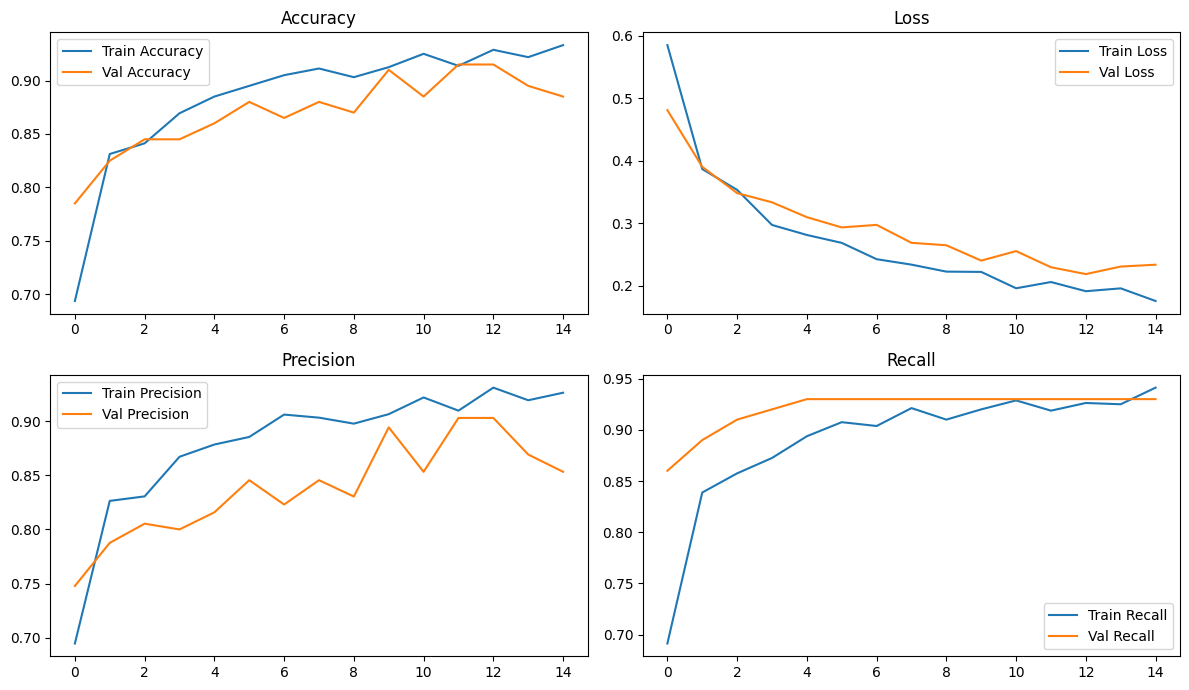

In [ ]:
plt.figure(figsize=(12, 7))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

# Precision
if "precision" in history.history:
    plt.subplot(2, 2, 3)
    plt.plot(history.history["precision"], label="Train Precision")
    plt.plot(history.history["val_precision"], label="Val Precision")
    plt.title("Precision")
    plt.legend()

# Recall
if "recall" in history.history:
    plt.subplot(2, 2, 4)
    plt.plot(history.history["recall"], label="Train Recall")
    plt.plot(history.history["val_recall"], label="Val Recall")
    plt.title("Recall")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_results = model.evaluate(test_ds, return_dict=True)
print(test_results)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step - accuracy: 0.8900 - loss: 0.2490 - precision: 0.9643 - recall: 0.8100    
{'accuracy': 0.8899999856948853, 'loss': 0.24898424744606018, 'precision': 0.9642857313156128, 'recall': 0.8100000023841858}


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 714ms/step
                precision    recall  f1-score   support

non_recyclable       0.84      0.97      0.90       100
    recyclable       0.96      0.81      0.88       100

      accuracy                           0.89       200
     macro avg       0.90      0.89      0.89       200
  weighted avg       0.90      0.89      0.89       200



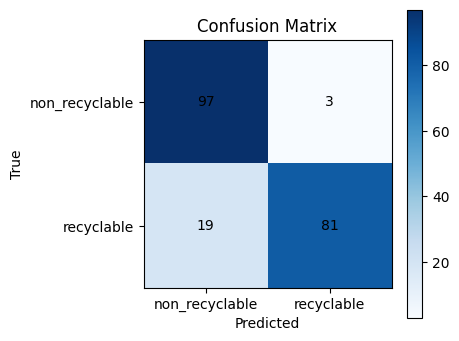

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs.ravel() > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=["non_recyclable", "recyclable"]))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["non_recyclable", "recyclable"])
plt.yticks([0,1], ["non_recyclable", "recyclable"])
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

In [ ]:
model.save("model/stage1_mobilenetv3_classifier.h5")

print("Stage 1 MobileNet training complete.")
print("Model saved as 'stage1_mobilenetv3.keras.h5")

Stage 1 MobileNet training complete.
Model saved as 'stage1_mobilenetv3.keras.h5
